# Regressione lineare

**Esempio**. Stima empirica del tempo di percorrenze di un itinerario escursionistico a partire dalla lunghezza $L$ e dal dislivello positivo $D$. La *regola di Naismith* afferma che bisogna prevedere un'ora per ogni miglio di percorrenze più un'ora ogni 2000 piedi di salita. Tradotto in km e metri

$$
t \approx \frac{L(km)}{5} + \frac{D(m)}{600}
$$

Esiste una formula equivalente per stimare la durati di una gara di corsa in montagna?

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(os.path.join('dataset', 'trail_running.csv'), sep=';')
df.columns = ['Gara', 'Lunghezza', 'D+', 'Tempo']
df['Lunghezza'] = df['Lunghezza']*1000

In [ ]:
df

In [ ]:
df['Tempo']

In [3]:
df['Tempo'] = pd.to_timedelta(df['Tempo']).dt.total_seconds()/60
df.columns = ['Gara', 'Lunghezza', 'D+', 'Minuti']

In [ ]:
df

In [ ]:
plt.scatter(df['Lunghezza'], df['Minuti'], marker='.')

Scartiamo i percorsi della lunghezza superiore ai 100km usando un filtro sulle righe del dataframe.

Il filtro:

In [ ]:
df['Lunghezza'] < 100000

Utilizzo del filtro

In [4]:
# oltre 100km intervengono in modo più importante altre caratteristiche non considerate
# scartati = df.shape[0] - (df['Lunghezza'] < 100000).shape[0]
df = df[df['Lunghezza'] < 100000]

In [ ]:
print(df.shape)

In [ ]:
plt.scatter(df['Lunghezza'], df['Minuti'], marker='.')

# Regressione lineare

Predirre il valore di una variabile su scala continua usando i valori delle caratteristiche. Nel caso la relazione sia lineare si cercano i coefficienti di un iperpiano

$$
y = w_0 + \sum_{i=1}^{d} w_i x_i.
$$

Dove il vettore $x = (x_1,\ldots, x_d)$ è definito nello spazio delle caratteristiche e $w=(w_0,\ldots, w_d)$ sono i coefficienti dell'iperpiano. L'iperpiano deve approssimare nel miglior modo possibile i dati osservati

<img src="02-01-gradient.png" alt="descrizione" width="50%">


Assumendo che:

- $x_0$ sia sempre $1$
- $w = (w_0,\ldots, w_d)$ e $x = (1, x_1,\ldots, x_d)$ 

$$
y = w_0 + \sum_{i=1}^{d} w_i x_i = \sum_{i=0}^{d} w_i x_i = w \cdot x.
$$

dove $\cdot$ indica il prodotto scalare.

Utilizzando gli $n$ campioni di addestramento, le cui features sono codificate nella matrice $X \in R^{n\times d}$, e i cui output nel vettore $y \in R^n$, vogliamo trovare $w^*$ che minimizzi l'errore $J(w)$. Questo può essere definito come  **somma degli errori quadrati** (il fattore 2 serve per comodità quando si passa alle derivate)

$$
J(w) = \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

Nella precedene equazione, con la notazione $x^{(i)}$ e $y^{(i)}$ viene indicato il vettore delle features dell'esempio $i$ ed il suo output. Pertanto $x^{(i)} \in R^{d}$ mentre  $y^{(i)} \in R$.

## Discesa del gradiente

La formula chiusa per il calcolo dei coefficienti della regressione lineare ($(X^T X)^{-1} X^T y$) ha un costo computazionale elevato, sia di tempo che di memoria, in quanto richiede moltiplicazioni e inversioni di matrici. Per questo si preferisce l'algoritmo di **discesa del gradiente** molto più efficiente e scalabile a dataset molto grandi.

Troviamo $w^*$ che minimizza $J(w)$ utilizzando l'algoritmo di discesa del gradiente. L'idea è aggiornare una soluzione corrente $w$ spostandoci in direzione opposta al gradiente (che indica la direzione di massima pendenza positiva). L'approccio funziona se la funzione è derivabile e convessa (in questo modo il minimo è unico). Quindi

$$
w \leftarrow w + \Delta w = w -\eta \nabla J(w)
$$

dove $\nabla J(w)$ indica il vettore delle derivate parziali (gradiente di $J$). La costante $\eta$ è chiamata **tasso di apprendimento** e controlla di quanto ci si sposta in funzione del gradiente. Andiamo a calcolare il valore delle componenti di $\nabla J(w)$.

$$
\frac{\partial J}{\partial w_j} = \frac{\partial}{\partial w_j} \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

$$
= \frac{1}{2}\sum_{i=1}^n 2  \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - w\cdot x^{(i)} \right)
$$

$$
 = \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - \sum_{k=1}^{d}w_k\cdot x^{(i)}_k \right)
$$

$$
= \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)(-x^{(i)}_j)
$$

$$
=-\sum_{i=1}^n x^{(i)}_j \left( y^{(i)} - w\cdot x^{(i)} \right)
$$

<!----$$
= - x_j\cdot(y-w\cdot x^{(i)})
$$-->

Dove $x_j$ rappresenta la colonna $j$ di $X$ e $x^{(i)}$ indica la riga $i$.  Quindi, la precedente può essere riscritta come al prodotto scalare del vettore colonna $j$ di $X$ per il vettore

$$
\texttt{errors} = \left(
\begin{array}{c}
y^{(1)}-w\cdot x^{(1)}\\
\vdots\\
y^{(n)}-w\cdot x^{(n)}
\end{array}
\right)
$$

quindi

$$
\nabla J(w) = - X^T\times \texttt{errors}
$$

Dove il precedente è un prodotto matrice-vettore.


```python
'''
Parametri: X, matrice di addestramento; y, vettore etichette; eta, tasso di apprendimento;
'''
        for _ in range(max_num_iterations):
            errors = (y -  np.dot(X, w[1:]) + w[0] )
            w[1:] += eta * X.T.dot(errors)
            w[0]  += eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            costs.append(cost)
```

L'aggiornamento di `w[0]` si spiega con il valore pari a `1` relativo alla variabile fittizia il cui peso è il termine noto. Questo induce una colonna di `1` della matrice $X$ (una riga in $X^T$).


### Codifica

Con valori elevati delle features si rischia l'overflow. Meglio scalare tutto usando la *standardizzazione*. Questo viene fatto nel metodo `fit` e nel metodo `predict`.


In [ ]:
class LinearRegressionGD(object):
    def __init__(self, eta=0.001, n_iter=1000):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        # Standardizzazione delle feature
        # media 0, deviazione standard 1
        self.mean_ = X.mean(axis=0) # media per colonne;   COSTO Theta(nd)
        self.std_ = X.std(axis=0)   # deviazione standard per colonne; COSTO Theta(nd)
        X_std = (X - self.mean_) / self.std_ # COSTO Theta(nd)

        # Inizializzazione pesi
        self.w_ = np.zeros(1 + X.shape[1]) # COSTO Theta(d)

        for _ in range(self.n_iter):  # per n_iter volte
            output = self.net_input(X_std)  # COSTO Theta(nd)
            errors = y - output  # COSTO Theta(n)
            self.w_[1:] += self.eta * X_std.T.dot(errors)/X.shape[0] # COSTO Theta(nd)
            self.w_[0] += self.eta * errors.sum()/X.shape[0] # # COSTO Theta(n)
            # divisione per X.shape[0] per maggiore stabilità
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # Standardizza i dati usando media e std del training set
        X_std = (X - self.mean_) / self.std_
        return self.net_input(X_std)
    
    def get_coef(self):
        """
        Restituisce i coefficienti e l'intercetta del modello
        riferiti ai dati originali (non standardizzati).
        """
        # Coefficienti originali
        coef = self.w_[1:] / self.std_
        
        # Intercetta originale
        intercept = self.w_[0] - np.sum(self.w_[1:] * self.mean_ / self.std_)
        
        return intercept, coef


Il metodo `get_coef` restituisce la intercetta e i coefficienti originali (senza standardizzazione). Standardizzando abbiamo introdotto questa trasformazione

$$
x_i^{\texttt{std}} = \frac{x_i - \mu_i}{\sigma_i}
$$

Partendo da

$$
y = w_0^{\texttt{std}} + \sum_{i=1}^{d} w_i^{\texttt{std}} x_i^{\texttt{std}}
$$

allora

$$
y = w_0^{\texttt{std}} + \sum_{i=1}^{d} w_i^{\texttt{std}} \frac{x_i - \mu_i}{\sigma_i}
$$

da cui segue

$$
y = w_0^{\texttt{std}} - \sum_{i=1}^{d} \frac{w_i^{\texttt{std}} \mu_i}{\sigma_i}   +  \sum_{i=1}^{d} \frac{w_i^{\texttt{std}}}{\sigma_i} x_i.
$$

Quindi nello spazio delle feature originali abbiamo i seguenti valori per intercetta e coefficienti:

$$
w_0^{\texttt{std}} - \sum_{i=1}^{d} \frac{w_i^{\texttt{std}} \mu_i}{\sigma_i}, \quad
\left(\frac{w_1^{\texttt{std}}}{\sigma_1},\ldots,\frac{w_d^{\texttt{std}}}{\sigma_d} \right)
$$

### Valutazione dell'errore

Se $y_i$ sono i valori reali e $z_i$ quelli predetti, l'**errore medio assoluto** (MAE, *mean absolute error*) è dato da

$$
\frac{1}{n}\sum_{i=1}^{n} |y_i - z_i|
$$

In [6]:
def mae(y, z):
    '''
    Calcola l'errore medio assoluto
    '''
    return np.sum(np.abs(y-z))/y.shape[0]

In [ ]:
X = df[ ['Lunghezza'] ].values
y = df['Minuti'].values

linreg = LinearRegressionGD(eta=0.002, n_iter=2000)

linreg.fit(X, y)

previsioni = linreg.predict(X)

# Valori reali che il modello sta cercando di prevedere
valori_reali = y

# Calcolo del Mean Absolute Error
error = mae(valori_reali, previsioni)

print(f"Mean Absolute Error (MAE): {error:.2f}")

Mean Absolute Error (MAE): 22.13


In [8]:
linreg.get_coef()

(np.float64(1.6325517193887151), array([0.00346154]))

[2.53480693]


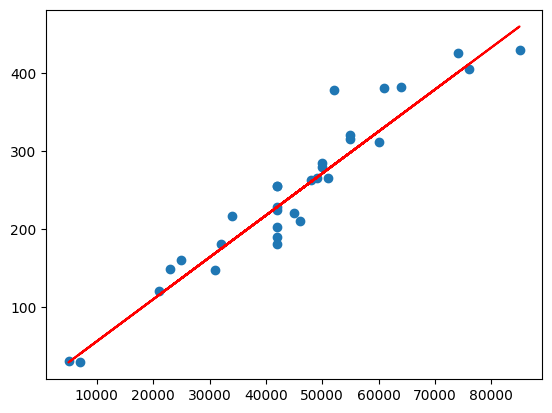

In [13]:
plt.scatter(X, y)
plt.plot(X, previsioni, c='r')
print(linreg.predict(np.array([[0]])))

In [17]:
X = df['D+'].values.reshape(-1,1)
# oppure X = df[['D+']].values
y = df['Minuti']

linreg = LinearRegressionGD(eta=0.002, n_iter=3000)

linreg.fit(X, y)

previsioni = linreg.predict(X)

# Valori reali che il modello sta cercando di prevedere
valori_reali = y

# Calcolo del Mean Absolute Error
error = mae(valori_reali, previsioni)

print(f"Mean Absolute Error (MAE): {error:.2f}")

Mean Absolute Error (MAE): 50.84


[68.69628864]


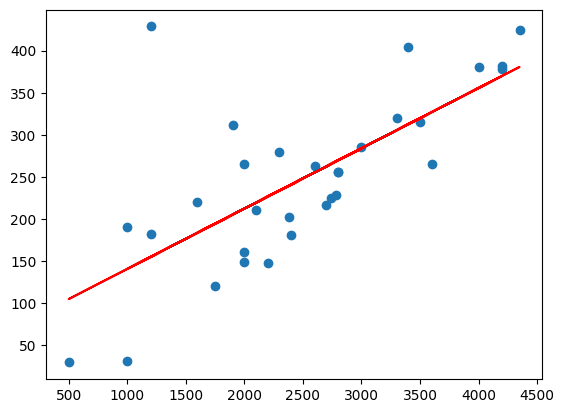

In [18]:
plt.scatter(X, y)
plt.plot(X, previsioni, c='r')
print(linreg.predict(np.array([[0]])))

In [21]:
X = df[ ['Lunghezza', 'D+'] ].values 
y = df['Minuti']

linreg = LinearRegressionGD(eta = 0.01, n_iter=2500)

linreg.fit(X, y)

previsioni = linreg.predict(X)

# oppure usando i intercetta e coefficienti
intercept, coef = linreg.get_coef()
previsioni = intercept + np.dot(X, coef)

# Valori reali che il modello sta cercando di prevedere
valori_reali = y

# Calcolo del Mean Absolute Error
error = mae(valori_reali, previsioni)

print(f"Mean Absolute Error (MAE): {error:.2f}")

Mean Absolute Error (MAE): 14.09


In [ ]:
print(intercept, coef)

**Esercizio 1**: calcolare la complessità dell'algoritmo di addestramento (metodo `fit`) in funzione delle dimensioni del dataset e del parametro `n_iter`.

**Esercizio 2**: modificare l'implementazione della classi `LinearRegressionGD` sostituendo il criterio di terminazione dell'addestramento facendo in modo che questo termini quando la funzione $J(w)$ smette di diminuire in modo significativo.